<a href="https://colab.research.google.com/github/Kartiksinghparihar/-DecodeLabs-Internship/blob/main/DecodeLabs_DS_Intern_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Task 1

In [ ]:
df=pd.read_excel("/content/Dataset for Data Analytics.xlsx")

In [ ]:
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [ ]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [ ]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [ ]:
df.dtypes

,0
OrderID,object
Date,datetime64[ns]
CustomerID,object
Product,object
Quantity,int64
UnitPrice,float64
ShippingAddress,object
PaymentMethod,object
OrderStatus,object
TrackingNumber,object


In [ ]:
df.shape

(1200, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# TASK **2**

In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [ ]:
df = df.drop(df.iloc[0:300][df.iloc[0:300]["CouponCode"].isna()].index)

In [ ]:
df.iloc[300:600, df.columns.get_loc("CouponCode")] = df.iloc[300:600, df.columns.get_loc("CouponCode")].fillna('None')

In [ ]:
df.iloc[600:, df.columns.get_loc("CouponCode")] = df.iloc[600:, df.columns.get_loc("CouponCode")].ffill()


In [ ]:
df["CouponCode"] = df["CouponCode"].astype(str).str.strip().str.title()


In [ ]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


# Task 3

In [ ]:
print(df["Quantity"].mean())
print(df["Quantity"].median())
print(df["Quantity"].mode()[0])
print(df["Quantity"].std())

2.9376114081996434
3.0
1
1.412835514634668


In [ ]:
print(df["TotalPrice"].mean())
print(df["TotalPrice"].median())
print(df["TotalPrice"].mode()[0])
print(df["TotalPrice"].std())

1050.1002049910874
818.0699999999999
211.14
821.3637267262724


In [ ]:
print(df["UnitPrice"].mean())
print(df["UnitPrice"].median())
print(df["UnitPrice"].mode()[0])
print(df["UnitPrice"].std())

356.38393939393944
364.025
127.18
197.77438017115762


In [ ]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.011400,0.648101,0.615476
UnitPrice,0.011400,1.000000,-0.004130,0.714291
ItemsInCart,0.648101,-0.004130,1.000000,0.386174
TotalPrice,0.615476,0.714291,0.386174,1.000000


In [ ]:
df["Date"]=pd.to_datetime(df["Date"])
df.set_index('Date',inplace=True)
df["7_Day_Avg_Quantity"]=df["Quantity"].rolling(window=7).mean()
df["14_Day_Avg_Quantity"]=df["Quantity"].rolling(window=14).mean()
df

,OrderID,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,7_Day_Avg_Quantity,14_Day_Avg_Quantity
Date,,,,,,,,,,,,,,,
2023-01-04,ORD200000,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,Save10,Instagram,2853.10,NaN,NaN
2024-08-23,ORD200001,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,Save10,Referral,302.70,NaN,NaN
2024-02-27,ORD200002,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,Freeship,Email,2753.40,NaN,NaN
2023-10-15,ORD200003,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,Save10,Facebook,273.19,NaN,NaN
2025-05-08,ORD200004,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,Save10,Email,2504.04,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-20,ORD201195,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,Freeship,Google,107.04,2.857143,2.142857
2024-03-04,ORD201196,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,Freeship,Facebook,1325.06,2.428571,2.142857
2023-07-13,ORD201197,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,Freeship,Instagram,873.68,2.285714,2.214286


In [ ]:
q1=df['Quantity'].quantile(0.25)
q3=df['Quantity'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outlier=df[(df['Quantity']<lower_bound) | (df['Quantity']>upper_bound)]
print(len(outlier))

0


In [ ]:
q1=df['TotalPrice'].quantile(0.25)
q3=df['TotalPrice'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outlier=df[(df['TotalPrice']<lower_bound) | (df['TotalPrice']>upper_bound)]
print(len(outlier))

12


In [ ]:
q1=df['UnitPrice'].quantile(0.25)
q3=df['UnitPrice'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outlier=df[(df['UnitPrice']<lower_bound) | (df['UnitPrice']>upper_bound)]
print(len(outlier))

0


In [ ]:
z_score=np.abs(stats.zscore(df['ItemsInCart']))
threshold=3
outliers=np.where(z_score>threshold)
print(outliers)

(array([], dtype=int64),)


In [ ]:
z_score=np.abs(stats.zscore(df['TotalPrice']))
threshold=3
outliers=np.where(z_score>threshold)
print(outliers)

(array([], dtype=int64),)


# Task 4

In [ ]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

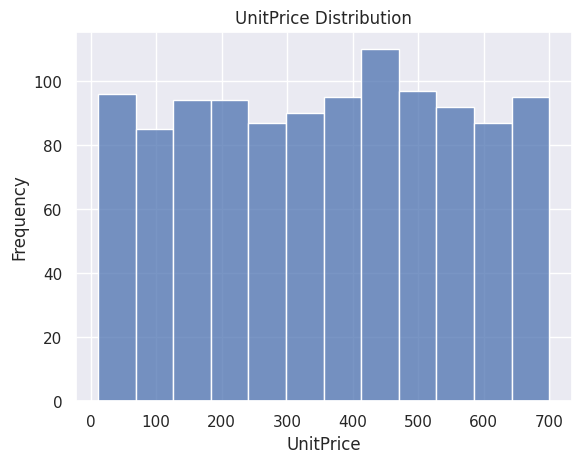

In [ ]:
sns.histplot(df["UnitPrice"])
plt.title("UnitPrice Distribution")
plt.xlabel("UnitPrice")
plt.ylabel("Frequency")
plt.show()

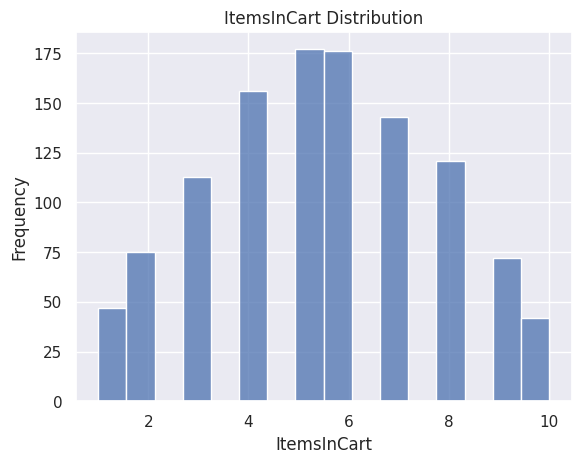

In [ ]:
sns.histplot(df["ItemsInCart"])
plt.title("ItemsInCart Distribution")
plt.xlabel("ItemsInCart")
plt.ylabel("Frequency")
plt.show()

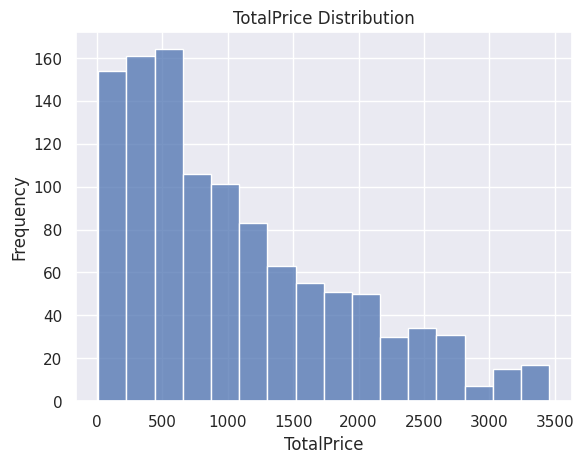

In [ ]:
sns.histplot(df["TotalPrice"])
plt.title("TotalPrice Distribution")
plt.xlabel("TotalPrice")
plt.ylabel("Frequency")
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

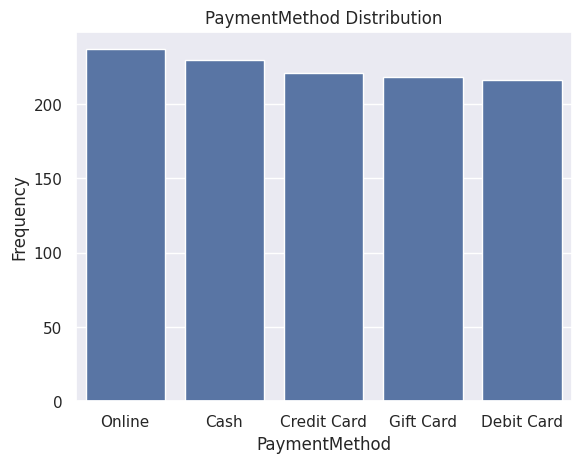

In [ ]:
counts=df["PaymentMethod"].value_counts()
sns.barplot(x=counts.index,y=counts.values)
plt.title("PaymentMethod Distribution")
plt.xlabel("PaymentMethod")
plt.ylabel("Frequency")
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

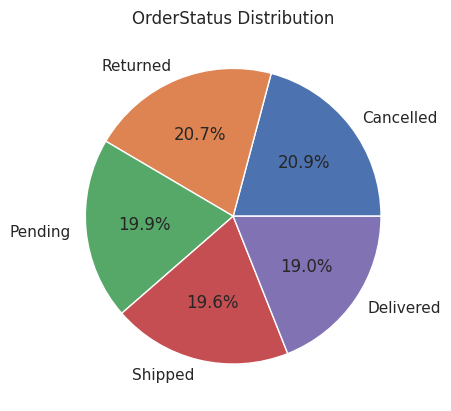

In [ ]:
counts=df["OrderStatus"].value_counts()
plt.pie(counts,labels=counts.index,autopct='%1.1f%%')
plt.title("OrderStatus Distribution")
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

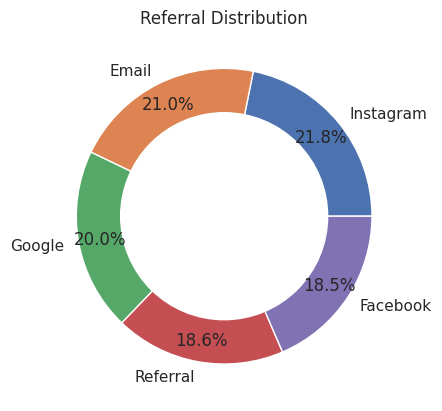

In [ ]:
counts=df["ReferralSource"].value_counts()
plt.pie(counts,labels=counts.index,autopct='%1.1f%%',pctdistance=0.85)
centre_circle=plt.Circle((0,0),0.70,fc='white')
fig=plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Referral Distribution")
plt

/tmp/ipykernel_8975/4245092760.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="OrderStatus",y="TotalPrice",palette='muted')


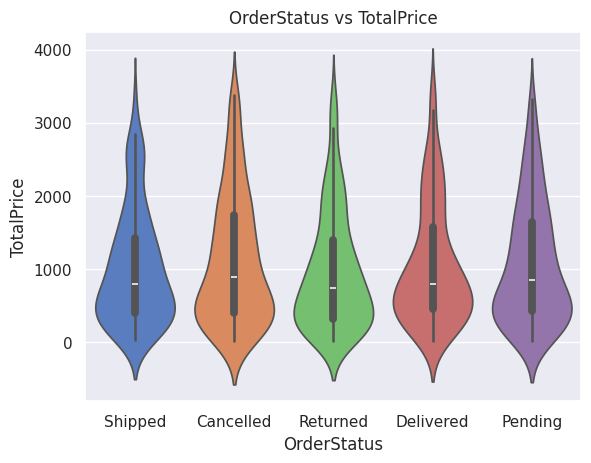

In [ ]:
sns.violinplot(data=df,x="OrderStatus",y="TotalPrice",palette='muted')
plt.title("OrderStatus vs TotalPrice")
plt.xlabel("OrderStatus")
plt.ylabel("TotalPrice")
plt.show()

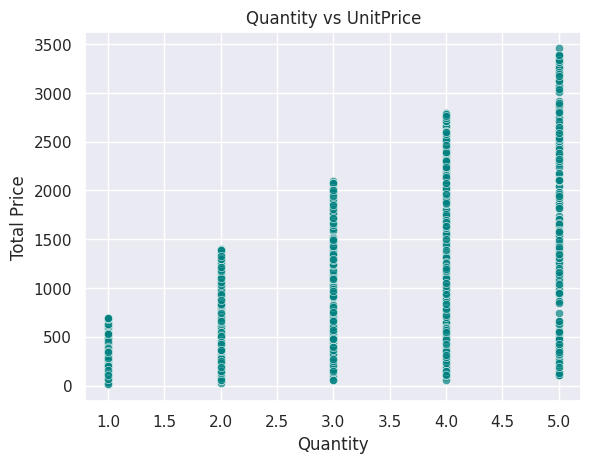

In [ ]:
sns.scatterplot(data=df,x='Quantity',y='TotalPrice',alpha=0.7,color='teal')
plt.title("Quantity vs UnitPrice")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.show()

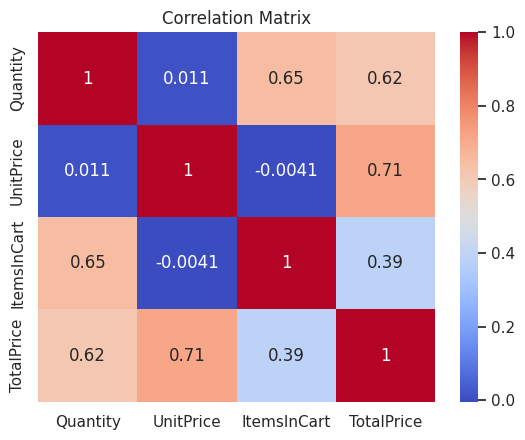

In [ ]:
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


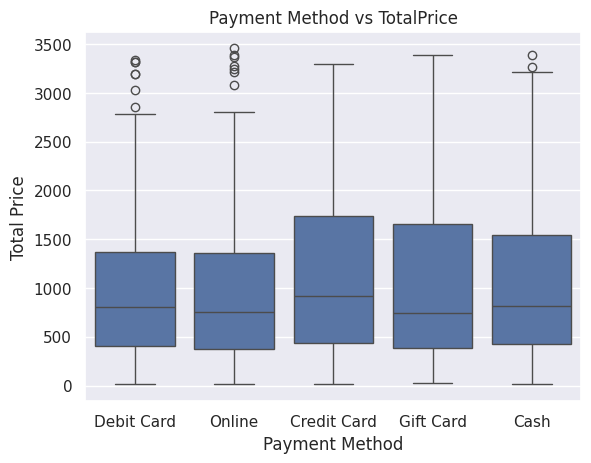

In [ ]:
sns.boxplot(data=df,x="PaymentMethod",y="TotalPrice")
plt.title("Payment Method vs TotalPrice")
plt.xlabel("Payment Method")
plt.ylabel("Total Price")
plt.show()

# Task 5

Regression

In [ ]:
x=df[["Quantity","ItemsInCart","UnitPrice"]]
y=df["TotalPrice"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
reg_model=LinearRegression()
reg_model.fit(x_train,y_train)
y_pred=reg_model.predict(x_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):.2f}")


R-squared Score: 0.87
Mean Absolute Error: $206.56


Classification


In [ ]:
df["Is_succesfull"]=df["OrderStatus"].apply(lambda x: 1 if x=="Delivered" else 0)
x=df[["Quantity","ItemsInCart","UnitPrice","TotalPrice"]]
y=df["Is_succesfull"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
clf_model=LogisticRegression()
clf_model.fit(x_train,y_train)
y_pred=clf_model.predict(x_test)
print(classification_report(y_test,y_pred))
print(f"Accuracy: {accuracy_score(y_test,y_pred):.2f}")

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       180
           1       0.00      0.00      0.00        45

    accuracy                           0.80       225
   macro avg       0.40      0.50      0.44       225
weighted avg       0.64      0.80      0.71       225

Accuracy: 0.80


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


THANK YOU